In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime

movies_df = pd.read_csv("Datasets/clean_movies.csv")
# cast_df = pd.read_csv("Datasets/clean_cast.csv")
# crew_df = pd.read_csv("Datasets/clean_crew.csv")
keyword_df = pd.read_csv("Datasets/keywords.csv")
# keyword_df = pd.read_csv("Datasets/clean_keyword.csv")
genres_df = pd.read_csv("Datasets/clean_genres.csv")
# production_df = pd.read_csv("Datasets/clean_production.csv")

In [ ]:
#merge genres and keywords
# combined_df = pd.merge(genres_df, keyword_df, on='id')

In [13]:
movies_df = pd.merge(movies_df, keyword_df, on='id')

In [14]:
#try a new supervised model that will make a guess about whether a movie will be popular / profitable
#create a new derived value.  is_flop popularity < mean, profit < mean use 


#sift out low value rows
movies_df = movies_df[(movies_df['popularity'] != 0) & (movies_df['vote_count'] > 10)]
movies_df = movies_df[(movies_df['budget'] > 500) & (movies_df['revenue'] > 500)]

movies_df['profit'] = movies_df['revenue'] - movies_df['budget']
profit_avg = movies_df['profit'].mean().round(2)
pop_avg = movies_df['popularity'].mean()

print(f"The average profit from this collection is ${profit_avg}")
print(f"The average popularity from this collection is {pop_avg}")

The average profit from this collection is $62715163.93
The average popularity from this collection is 10.269561019656967


In [ ]:
# movies_df['is_flop'] = (movies_df['popularity'] < pop_avg) & (movies_df['profit'] < 0)
# print(movies_df['is_flop'].value_counts())


In [15]:
#try a broader context
movies_df['is_flop'] = (movies_df['profit'] < 0)
print(movies_df['is_flop'].value_counts())

is_flop
False    3691
True     1498
Name: count, dtype: int64


In [16]:
X = movies_df['movie_text'].values
y = movies_df['is_flop'].values

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

In [18]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer, HashingVectorizer
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC


vectorizers = {
    "CountVectorizer": CountVectorizer(),
    "TfidfVectorizer": TfidfVectorizer(),
    "HashVectorizer": HashingVectorizer(n_features=2**20)
}

classifiers = {
    "KNeighborsClassifier": KNeighborsClassifier(n_neighbors=3),
    "SVM": SVC(),
    "LogisticRegression": LogisticRegression(),
    "LinearSVC": LinearSVC()
}

# Create the pipelines combining the above vectorizers and classifiers
# Suggestion: Create the pipelines as a dictionary of name->pipeline where `name` describes the vectorizer and classifier used.
pipelines = {
    # "count-kn": make_pipeline(CountVectorizer(stop_words='english'), KNeighborsClassifier()),
    # # "Embed-SVM": make_pipeline(SentenceTransformerEmbedding(), SVC()),
    # "Hashing-SVM": make_pipeline(HashingVectorizer(n_features=2**20), SVC()),
    # "Hashing-Logistic": make_pipeline(HashingVectorizer(n_features=2**20), LogisticRegression()),
    # "TfIdf-KN": make_pipeline(TfidfVectorizer(stop_words='english'), KNeighborsClassifier(n_neighbors=3)),
    "TfIdf-Logistic": make_pipeline(TfidfVectorizer(stop_words='english'), LogisticRegression(class_weight='balanced',max_iter=1000)),
    # "Linear-SVC": make_pipeline(TfidfVectorizer(stop_words='english'), LinearSVC(dual=False))   
    # "Embed-Logistic": make_pipeline(SentenceTransformerEmbedding(),LogisticRegression())
}

In [ ]:
# pipelines["count-kn"].fit(X_train,y_train)
# pipelines["Hashing-SVM"].fit(X_train,y_train)
# pipelines["Hashing-Logistic"].fit(X_train,y_train)
# pipelines["TfIdf-KN"].fit(X_train,y_train)
# pipelines["TfIdf-Logistic"].fit(X_train,y_train)
# pipelines["Linear-SVC"].fit(X_train,y_train)

In [19]:
from sklearn.metrics import accuracy_score

acc_scores_list = []

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    score = accuracy_score(y_test, y_pred)
    
    print(f"{name} Score: {score}")
    
    acc_scores_list.append({'Model': name, 'Accuracy': score})

TfIdf-Logistic Score: 0.6840077071290944


In [20]:
from sklearn.metrics import classification_report

for name, pipe in pipelines.items():
    y_pred = pipe.predict(X_test)
    
    print(f"\n" + "*"*55)
    print(f" CLASSIFICATION REPORT: {name}")
    print("*"*55)
    
    print(classification_report(y_test, y_pred))


*******************************************************
 CLASSIFICATION REPORT: TfIdf-Logistic
*******************************************************
              precision    recall  f1-score   support

       False       0.78      0.78      0.78       732
        True       0.46      0.46      0.46       306

    accuracy                           0.68      1038
   macro avg       0.62      0.62      0.62      1038
weighted avg       0.68      0.68      0.68      1038



In [21]:

vec = pipelines["TfIdf-Logistic"].named_steps['tfidfvectorizer']
clf = pipelines["TfIdf-Logistic"].named_steps['logisticregression']

weights = pd.Series(clf.coef_[0], index=vec.get_feature_names_out())

print("Top 10 Flop Keywords:")
print(weights.sort_values(ascending=False).head(10))

print("\nTop 10 Success Keywords:")
print(weights.sort_values(ascending=True).head(10))


Top 10 Flop Keywords:
drama            2.917856
independent      2.695720
save             1.596129
film             1.581599
creek            1.424859
morgan           1.422640
films            1.364902
entertainment    1.239312
france           1.224657
brother          1.195835
dtype: float64

Top 10 Success Keywords:
universal      -1.835155
secret         -1.710955
fox            -1.583468
paramount      -1.508841
sequel         -1.477354
twentieth      -1.372934
house          -1.324482
relationship   -1.304260
school         -1.255045
self           -1.236011
dtype: float64


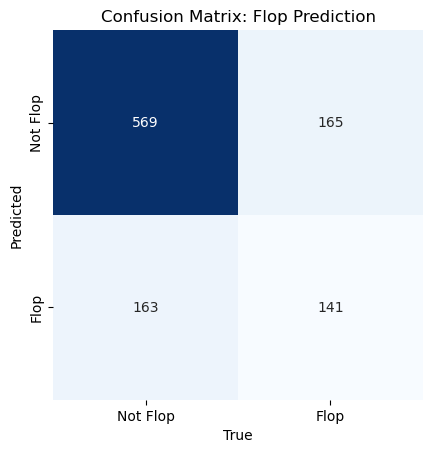

In [22]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

ypred = pipelines['TfIdf-Logistic'].predict(X_test)

mat = confusion_matrix(y_test, ypred)

sns.heatmap(mat.T, square=True, annot=True, fmt='d',
            cbar=False, cmap='Blues',
            xticklabels=['Not Flop', 'Flop'],
            yticklabels=['Not Flop', 'Flop'])

plt.xlabel('True')
plt.ylabel('Predicted')
plt.title('Confusion Matrix: Flop Prediction')
plt.show()
